# VIIRS NPP Land Surface Temperature (VNP21) — CONUS, multi-granule

Pulls VNP21 5-minute swath granules over CONUS via NASA Earthdata, concatenates the clear-sky 1 km LST pixels, then fits an EFGP with hyper-parameter learning and benchmarks against SKI.

**Why VNP21 instead of MOD11_L2?** MOD11_L2 ships as HDF-EOS2 (HDF4) and would need `pyhdf`. VNP21 (the operationally-supported VIIRS replacement, same idea / same resolution) ships as NetCDF4/HDF5 and reads cleanly with the same `xarray` + `netCDF4` stack as the SST notebook.

LST is the standard satellite proxy for near-surface air temperature in spatial statistics — far higher density than station networks (hundreds of thousands of points per granule, well into millions across a day), with rich correlation structure from topography, land cover, and urban heat islands.

Requires: `pip install earthaccess xarray netCDF4`. The first run will prompt for your NASA Earthdata credentials.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.optim import Adam

sys.path.append('../../..')
from efgpnd import EFGPND, _resolve_grid
from kernels import SquaredExponential
from kernels import ARDSquaredExponential
from utils.ski import fit_ski_gp
from load_modis_lst import download_viirs_lst, load_viirs_lst_swath, load_viirs_lst_torch

In [2]:
# Download VNP21 granules over CONUS. A few days' worth of swaths gives
# better fill across the bbox than just one day (Suomi-NPP only crosses
# CONUS ~3-4 times per day).
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

BBOX = (-125.0, 25.0, -66.0, 50.0)  # CONUS
TARGET_GRANULES = 20

existing = sorted(DATA_DIR.glob('VNP21*.nc')) + sorted(DATA_DIR.glob('VJ121*.nc'))
if len(existing) >= TARGET_GRANULES:
    granule_paths = existing[:TARGET_GRANULES]
    print(f'Using {len(granule_paths)} cached granules')
else:
    granule_paths = download_viirs_lst(
        short_name='VNP21',
        temporal=('2024-06-15', '2024-06-17'),  # 3-day window
        bounding_box=BBOX,
        count=TARGET_GRANULES,
        out_dir=DATA_DIR,
    )
    print(f'Downloaded {len(granule_paths)} granules')

for p in granule_paths[:5]:
    print(f'  {p.name}')
if len(granule_paths) > 5:
    print(f'  ... ({len(granule_paths) - 5} more)')

Using 20 cached granules
  VNP21.A2024167.0536.002.2024168033919.nc
  VNP21.A2024167.0542.002.2024168033917.nc
  VNP21.A2024167.0718.002.2024168033916.nc
  VNP21.A2024167.0724.002.2024168033917.nc
  VNP21.A2024167.0854.002.2024168033915.nc
  ... (15 more)


In [3]:
# Preview the first granule.
lon_grid, lat_grid, lst_grid, lst_meta = load_viirs_lst_swath(
    path=granule_paths[0],
    variable='LST',
    quality='good_only',   # alt: 'good_and_other' for more pixels (incl. cirrus)
    to_celsius=True,
    bbox=BBOX,
)
valid = np.isfinite(lst_grid)
print(f"Variable: {lst_meta['long_name']}")
print(f"Swath shape: {lst_grid.shape}")
print(f"Valid LST pixels: {valid.sum():,} / {valid.size:,}")
print(f"LST range: {np.nanmin(lst_grid):.2f} to {np.nanmax(lst_grid):.2f} {lst_meta['units']}")

Variable: Land Surface Temperature
Swath shape: (3232, 3200)
Valid LST pixels: 151,500 / 10,342,400
LST range: -9.07 to 20.65 Celsius


/var/folders/w7/6nm4rxb53x55tjtr3b5k86b80000gn/T/ipykernel_76751/1674799767.py:3: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(lon_grid, lat_grid, lst_plot, cmap='inferno', shading='auto', rasterized=True)


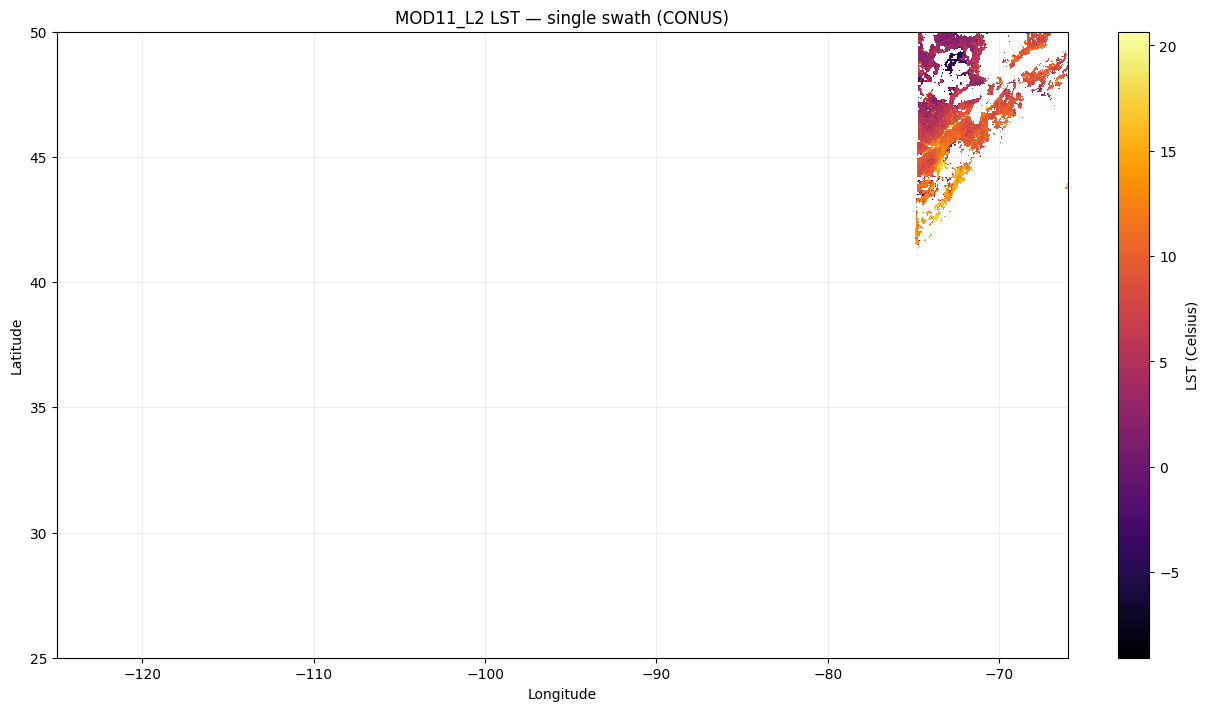

In [4]:
fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)
lst_plot = np.ma.masked_invalid(lst_grid)
pcm = ax.pcolormesh(lon_grid, lat_grid, lst_plot, cmap='inferno', shading='auto', rasterized=True)
ax.set_title('MOD11_L2 LST — single swath (CONUS)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_xlim(BBOX[0], BBOX[2]); ax.set_ylim(BBOX[1], BBOX[3])
ax.grid(alpha=0.2)
plt.colorbar(pcm, ax=ax, label=f"LST ({lst_meta['units']})")

In [5]:
# Concatenate clear-sky pixels across ALL granules.
x, y = load_viirs_lst_torch(
    path=granule_paths,
    variable='LST',
    quality='good_only',
    to_celsius=True,
    bbox=BBOX,
    n_sub=None,
    seed=0,
)
print(f'x shape: {tuple(x.shape)}')
print(f'y shape: {tuple(y.shape)}')
print(f'Lon range: {x[:, 0].min():.3f} to {x[:, 0].max():.3f}')
print(f'Lat range: {x[:, 1].min():.3f} to {x[:, 1].max():.3f}')
print(f"LST range: {y.min():.2f} to {y.max():.2f} {lst_meta['units']}")

x shape: (16493039, 2)
y shape: (16493039,)
Lon range: -124.999 to -66.000
Lat range: 25.000 to 50.000
LST range: -13.31 to 78.11 Celsius


Text(0.5, 0.98, 'VNP21 LST clear-sky pixels — 20 granules over CONUS')

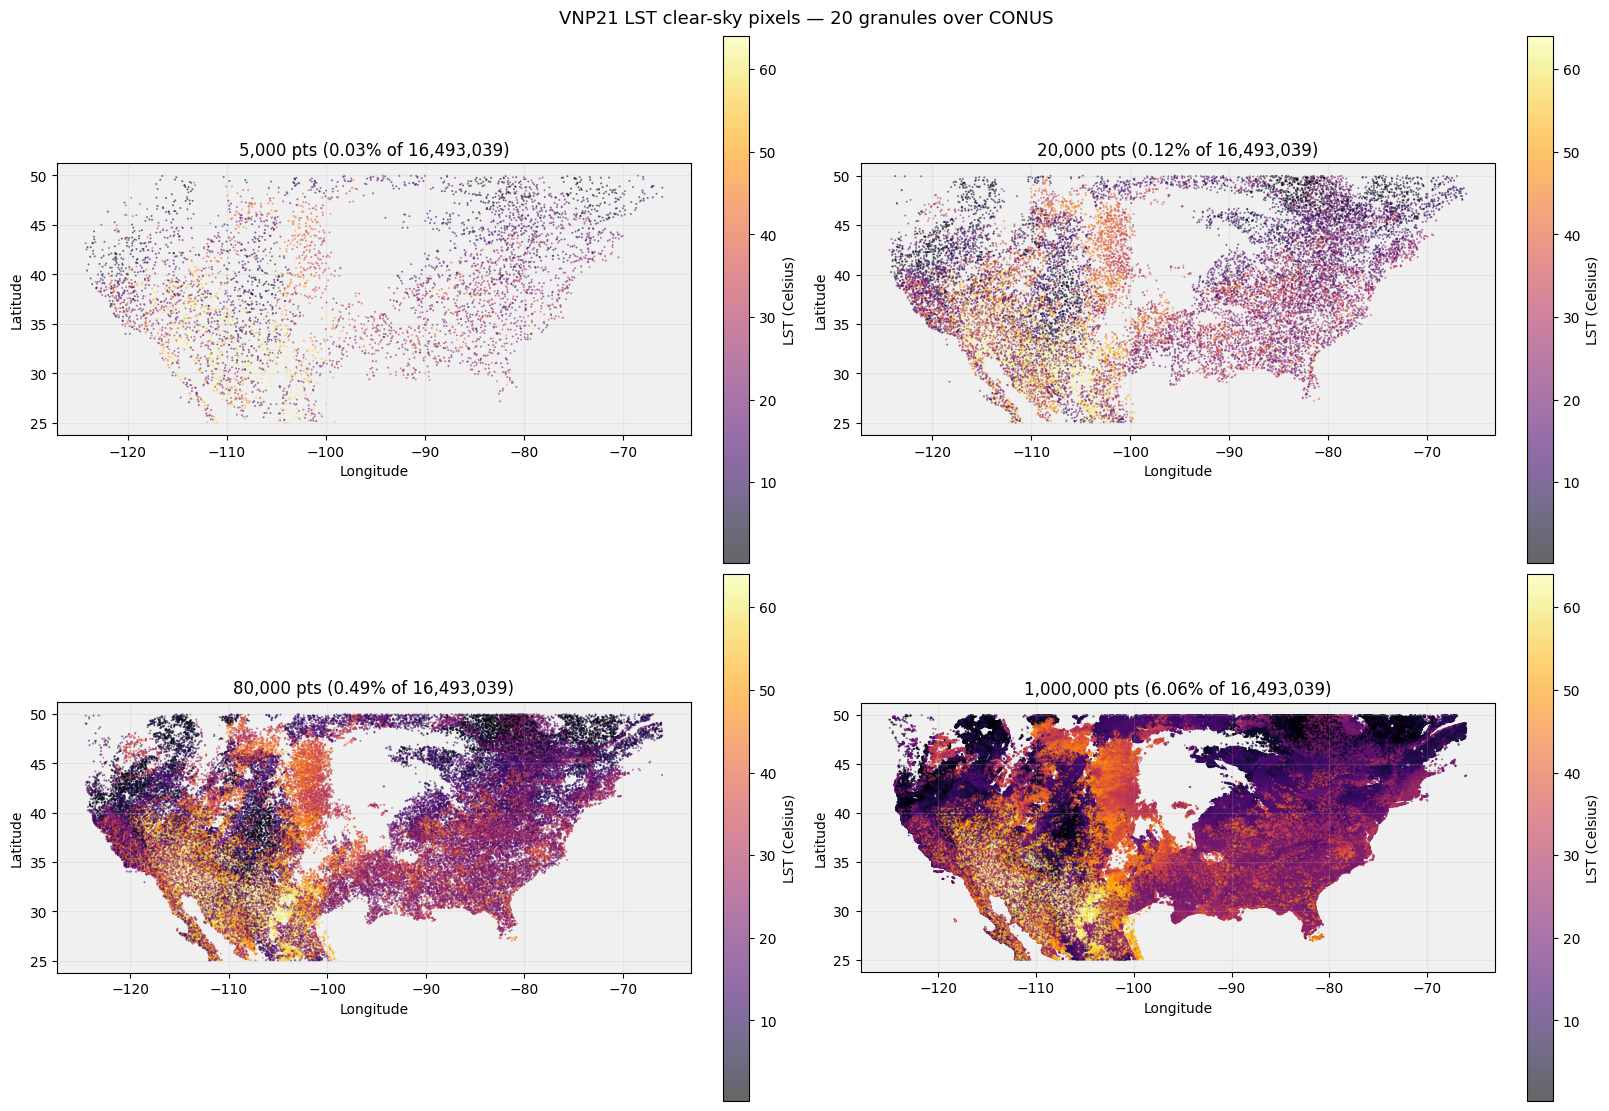

In [6]:
# Visualise the data at a few subsampling rates — too many points and you
# just see a coloured rectangle (swath stripes blur into solid color);
# too few and you miss the structure.
rng = np.random.default_rng(0)
sample_sizes = [5_000, 20_000, 80_000, 1_000_000]
vmin = float(np.nanpercentile(y.numpy(), 1))
vmax = float(np.nanpercentile(y.numpy(), 99))

fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
for ax, n_plot in zip(axes.ravel(), sample_sizes):
    n = min(n_plot, len(y))
    idx = rng.choice(len(y), size=n, replace=False)
    ax.set_facecolor('#f0f0f0')
    sc = ax.scatter(
        x[idx, 0].numpy(), x[idx, 1].numpy(),
        c=y[idx].numpy(), s=2.0, cmap='inferno', alpha=0.6,
        vmin=vmin, vmax=vmax, linewidths=0, rasterized=True,
    )
    frac = n / len(y) * 100
    ax.set_title(f'{n:,} pts ({frac:.2f}% of {len(y):,})')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    # ax.set_xlim(BBOX[0], BBOX[2]); ax.set_ylim(BBOX[1], BBOX[3])
    ax.set_aspect('equal')
    ax.grid(alpha=0.2)
    fig.colorbar(sc, ax=ax, label=f"LST ({lst_meta['units']})")
fig.suptitle(
    f'VNP21 LST clear-sky pixels — {len(granule_paths)} granules over CONUS',
    fontsize=13,
)

In [7]:
# x = x[idx]
# y= y[idx]

In [8]:
x_min, x_max = x.min(dim=0).values, x.max(dim=0).values
x = (x - x_min) / (x_max - x_min)

y_mean, y_std = y.mean(), y.std()
y = (y - y_mean) / y_std

print(f'x range per dim: {x.min(dim=0).values.tolist()} to {x.max(dim=0).values.tolist()}')
print(f'y mean={y.mean():.4f}, std={y.std():.4f}')

x = x.to(dtype=torch.float32)
y = y.to(dtype=torch.float32)

x range per dim: [0.0, 0.0] to [1.0, 1.0]
y mean=-0.0000, std=1.0000


In [13]:
d = x.shape[1]
EPSILON = 1e-3
cg_tol = 1e-4
noise_floor = 1e-4

init_ls = 0.3
init_var = 1.0
init_noise = 1.0

# Frozen-grid refresh schedule:
#   pin the frequency grid (and the Hutchinson trace probes) for K iterations,
#   then rebuild from the current hypers. This lets the M-space CG warm starts
#   actually apply (mean and trace), which dropped late-iter wall time ~3x in
#   the LST benchmark. Set to None to disable (refresh every iter, as before).
REFRESH_EVERY = 20

kernel_efgp = SquaredExponential(
    dimension=d, init_lengthscale=init_ls, init_variance=init_var
)
print(f'N = {x.shape[0]:,}, d = {d}')

N = 16,493,039, d = 2


In [15]:
max_iters = 200
J = 1

training_log = {
    'iter': [], 'lengthscale': [], 'variance': [], 'sigmasq': [],
    'mean_cg_iters': [], 'trace_cg_iters': [], 'mtot': [], 'feature_count': [],
    'wall_sec': [], 'grid_refreshed': [],
}

# trace_cg_warm_start and trace_probes_freeze are on by default in EFGPND;
# they pair with REFRESH_EVERY to give the trace solve its warm start.
model = EFGPND(
    x, y, kernel=kernel_efgp, sigmasq=init_noise, eps=EPSILON,
    estimate_params=False,
    opts={"mean_cg_preconditioner_type": "jacobi"},
)
optimizer = Adam(model.parameters(), lr=0.2)

training_log['iter'].append(0)
training_log['lengthscale'].append(model.kernel.get_hyper('lengthscale'))
training_log['variance'].append(model.kernel.get_hyper('variance'))
training_log['sigmasq'].append(model._gp_params.sig2.item())
for k in ('mean_cg_iters', 'trace_cg_iters', 'mtot', 'feature_count', 'wall_sec', 'grid_refreshed'):
    training_log[k].append(None)

import time as _time

frozen_grid = None
for it in range(max_iters):
    # Rebuild frozen_grid from the *current* hypers every REFRESH_EVERY iters.
    # On all other iters, reuse the previous (xis_1d_list, h_per_dim) so M is
    # stable and the cached mean/trace betas + frozen Hutchinson probes apply.
    if REFRESH_EVERY and it % REFRESH_EVERY == 0:
        xis_1d_list, h_per_dim, _, _ = _resolve_grid(
            model.kernel, model.x, EPSILON,
            rdtype=model.x.dtype, device=model.x.device,
        )
        frozen_grid = (xis_1d_list, h_per_dim)
        refreshed = True
    else:
        refreshed = False

    t0 = _time.perf_counter()
    optimizer.zero_grad()
    model.compute_gradients(
        trace_samples=J, cg_tol=cg_tol, noise_floor=noise_floor,
        frozen_grid=frozen_grid,
    )
    optimizer.step()
    dt = _time.perf_counter() - t0

    stats = model.last_gradient_stats
    mean_cg_iters = stats.get('mean_cg_iters')
    trace_cg_iters = stats.get('trace_cg_iters')
    mtot = stats.get('mtot')
    feature_count = stats.get('feature_count')

    lengthscale = model.kernel.get_hyper('lengthscale')
    variance = model.kernel.get_hyper('variance')
    sigmasq = model._gp_params.sig2.item()
    training_log['iter'].append(it + 1)
    training_log['lengthscale'].append(lengthscale)
    training_log['variance'].append(variance)
    training_log['sigmasq'].append(sigmasq)
    training_log['mean_cg_iters'].append(mean_cg_iters)
    training_log['trace_cg_iters'].append(trace_cg_iters)
    training_log['mtot'].append(mtot)
    training_log['feature_count'].append(feature_count)
    training_log['wall_sec'].append(dt)
    training_log['grid_refreshed'].append(refreshed)

    # Print every iter so the warm-start (non-refresh) iters are visible.
    # The leading "*" marks iters where the grid was rebuilt.
    flag = '*' if refreshed else ' '
    print(
        f"{flag} iter {it+1:>3}  {dt:5.2f}s  "
        f"ℓ={lengthscale:.4g}  σ_f²={variance:.4g}  σ_n²={sigmasq:.4g}  "
        f"cg(mean/trace)={mean_cg_iters}/{trace_cg_iters}  mtot={mtot}  M={feature_count}"
    )

print(
    f"\nFinal: ℓ={lengthscale:.4g}, σ_f²={variance:.4g}, σ_n²={sigmasq:.4g}, "
    f"cg(mean/trace)={mean_cg_iters}/{trace_cg_iters}, mtot={mtot}, M={feature_count}"
)
walls = [w for w in training_log['wall_sec'] if w is not None]
refresh_walls = [w for w, r in zip(walls, training_log['grid_refreshed'][1:]) if r]
warm_walls = [w for w, r in zip(walls, training_log['grid_refreshed'][1:]) if not r]
print(f"Total wall: {sum(walls):.1f}s")
if refresh_walls and warm_walls:
    print(f"  refresh iters (n={len(refresh_walls)}): mean {sum(refresh_walls)/len(refresh_walls):.2f}s")
    print(f"  warm iters    (n={len(warm_walls)}): mean {sum(warm_walls)/len(warm_walls):.2f}s")

* iter   1   1.35s  ℓ=0.2519  σ_f²=1.131  σ_n²=0.8783  cg(mean/trace)=242/82  mtot=11  M=121
  iter   2   0.08s  ℓ=0.2109  σ_f²=1.271  σ_n²=0.7674  cg(mean/trace)=242/54  mtot=11  M=121
  iter   3   0.07s  ℓ=0.1776  σ_f²=1.417  σ_n²=0.6697  cg(mean/trace)=242/54  mtot=11  M=121
  iter   4   0.08s  ℓ=0.1517  σ_f²=1.566  σ_n²=0.5901  cg(mean/trace)=242/46  mtot=11  M=121
  iter   5   0.49s  ℓ=0.1316  σ_f²=1.716  σ_n²=0.5368  cg(mean/trace)=242/56  mtot=11  M=121
  iter   6   0.06s  ℓ=0.116  σ_f²=1.866  σ_n²=0.5135  cg(mean/trace)=159/42  mtot=11  M=121
  iter   7   0.07s  ℓ=0.1037  σ_f²=2.017  σ_n²=0.5145  cg(mean/trace)=242/55  mtot=11  M=121
  iter   8   0.04s  ℓ=0.09388  σ_f²=2.168  σ_n²=0.5319  cg(mean/trace)=153/44  mtot=11  M=121
  iter   9   0.03s  ℓ=0.08607  σ_f²=2.319  σ_n²=0.5602  cg(mean/trace)=90/45  mtot=11  M=121
  iter  10   0.06s  ℓ=0.07983  σ_f²=2.47  σ_n²=0.5948  cg(mean/trace)=242/70  mtot=11  M=121
  iter  11   0.03s  ℓ=0.07482  σ_f²=2.621  σ_n²=0.6312  cg(mean/trace)

KeyboardInterrupt: 

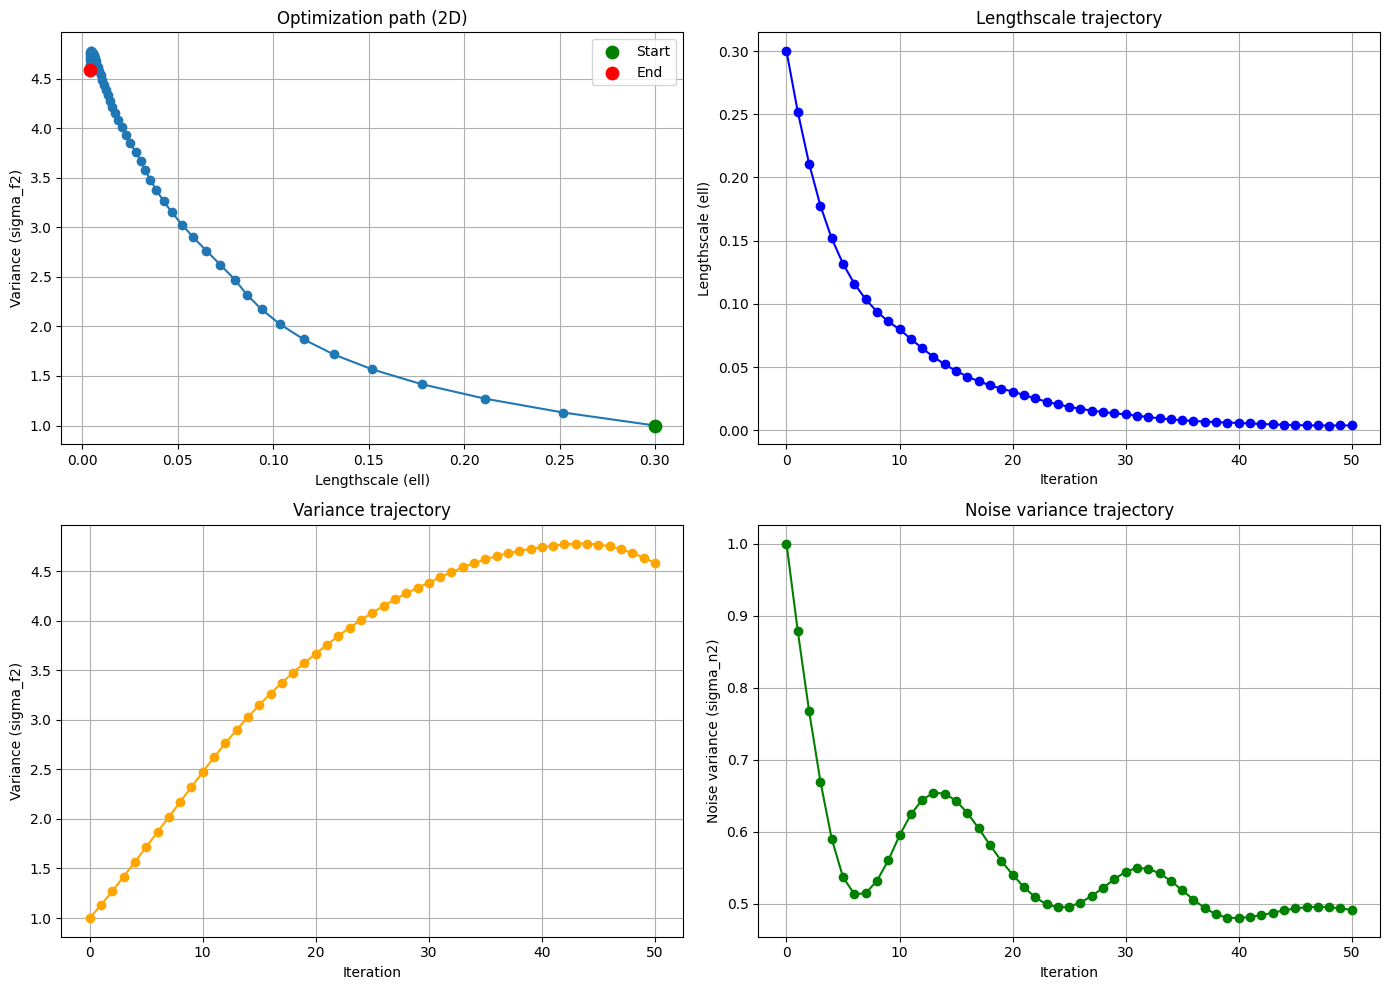

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
ax1.plot(training_log['lengthscale'], training_log['variance'], 'o-')
ax1.scatter(training_log['lengthscale'][0], training_log['variance'][0], color='green', s=80, label='Start', zorder=5)
ax1.scatter(training_log['lengthscale'][-1], training_log['variance'][-1], color='red', s=80, label='End', zorder=5)
ax1.set_xlabel('Lengthscale (ell)'); ax1.set_ylabel('Variance (sigma_f2)')
ax1.set_title('Optimization path (2D)'); ax1.legend(); ax1.grid(True)

axes[0, 1].plot(training_log['iter'], training_log['lengthscale'], 'o-', color='blue')
axes[0, 1].set_xlabel('Iteration'); axes[0, 1].set_ylabel('Lengthscale (ell)')
axes[0, 1].set_title('Lengthscale trajectory'); axes[0, 1].grid(True)

axes[1, 0].plot(training_log['iter'], training_log['variance'], 'o-', color='orange')
axes[1, 0].set_xlabel('Iteration'); axes[1, 0].set_ylabel('Variance (sigma_f2)')
axes[1, 0].set_title('Variance trajectory'); axes[1, 0].grid(True)

axes[1, 1].plot(training_log['iter'], training_log['sigmasq'], 'o-', color='green')
axes[1, 1].set_xlabel('Iteration'); axes[1, 1].set_ylabel('Noise variance (sigma_n2)')
axes[1, 1].set_title('Noise variance trajectory'); axes[1, 1].grid(True)
plt.tight_layout()